In [42]:
!pip install datasets huggingface_hub --upgrade
!pip install pydot graphviz
!pip install visualkeras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 8.5 MB/s eta 0:00:00


# **1. Import Necessary Libraries**

In [57]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from PIL import Image
import cv2
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from huggingface_hub import hf_hub_download
from keras.metrics import Precision, Recall, AUC
from tensorflow.keras.utils import plot_model
import visualkeras
import shap
plt.style.use('ggplot')
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Reproducability
np.random.seed(42)
tf.random.set_seed(42)

In [5]:
# Mount drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **2. Image Preprocessing**

In [6]:
# Constants used throughout
IMG_SIZE = (224,224)
BATCH_SIZE = 64
EPOCHS = 20

In [7]:
# Define directories
train_dir = "/content/drive/MyDrive/Colab Notebooks/DSGP Implementation/ImageSet/Dataset/train"
valid_dir = "/content/drive/MyDrive/Colab Notebooks/DSGP Implementation/ImageSet/Dataset/valid"
test_dir  = "/content/drive/MyDrive/Colab Notebooks/DSGP Implementation/ImageSet/Dataset/test"

In [8]:
def preprocess(img):
    """
    Applies medical image specific preprocessing:
    - Grayscale conversion
    - Gaussian blur for noise reduction
    - Normalization
    """
    # Convert to grayscale if RGB
    if len(img.shape) == 3:
        img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    else:
        img_gray = img

    # Apply Gaussian Blur to reduce noise
    img_blurred = cv2.GaussianBlur(img_gray, ksize=(3,3), sigmaX=0)

    # Normalize to [0, 1]
    img_normalized = img_blurred / 255.0

    # Convert to 3 channels if needed
    if img_normalized.ndim == 2:
        img_normalized = np.stack([img_normalized]*3, axis=-1)

    return img_normalized


In [9]:
# Data generators to normalize the images
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess,
    rotation_range=10,
    shear_range=0.01,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation & Test generator (no augmentation)
val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess
)

In [10]:
# Define data gens
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
    seed=42
)

val_gen = val_test_datagen.flow_from_directory(
    valid_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 2827 images belonging to 2 classes.
Found 700 images belonging to 2 classes.
Found 700 images belonging to 2 classes.


In [11]:
# Display the information for each gen
print(f"Training samples: {train_gen.samples}")
print(f"Validation samples: {val_gen.samples}")
print(f"Test samples: {test_gen.samples}")
print(f"Classes: {train_gen.class_indices}")

Training samples: 2827
Validation samples: 700
Test samples: 700
Classes: {'clean': 0, 'single_hotspot': 1}


In [12]:
# View class counts and class weights
class_counts = Counter(train_gen.classes)
total_samples = sum(class_counts.values())
class_weights = {cls: total_samples/(len(class_counts)*count) for cls, count in class_counts.items()}
print(f"Class counts: {class_counts}")
print(f"Class weights: {class_weights}")

Class counts: Counter({np.int32(1): 1749, np.int32(0): 1078})
Class weights: {np.int32(0): 1.3112244897959184, np.int32(1): 0.8081761006289309}


In [13]:
# Make synthetic datagen and train gen
synthetic_datagen = ImageDataGenerator(
    preprocessing_function=preprocess,
    rotation_range=5,
    shear_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode='reflect'
)

synthetic_train_gen = synthetic_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
    seed=42
)

Found 2827 images belonging to 2 classes.


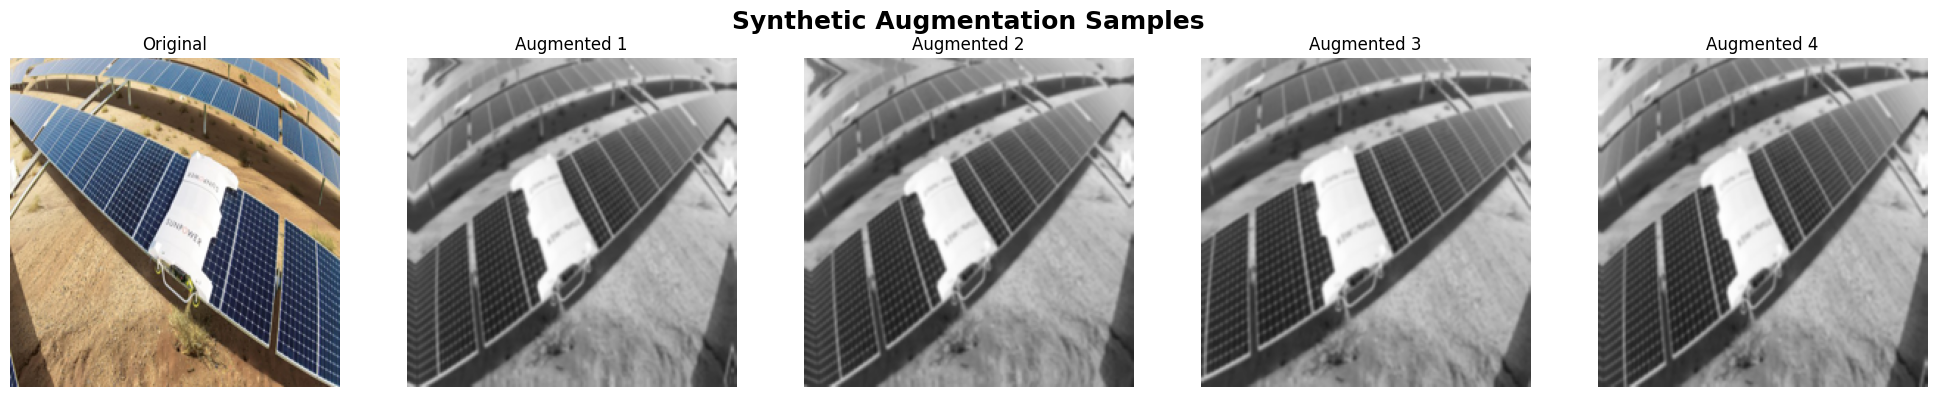

In [14]:
# Get a sample image
sample_img_path = os.path.join(train_dir, list(train_gen.class_indices.keys())[0],
                               os.listdir(os.path.join(train_dir, list(train_gen.class_indices.keys())[0]))[0])
sample_img = Image.open(sample_img_path).convert('RGB').resize(IMG_SIZE)
sample_array = np.expand_dims(np.array(sample_img), axis=0)

# Prepare for plotting
fig, axes = plt.subplots(1,5, figsize=(20,4))
axes[0].imshow(sample_img)
axes[0].set_title('Original')
axes[0].axis('off')

for i, batch in enumerate(synthetic_datagen.flow(sample_array, batch_size=1)):
    aug_img = (batch[0]*255).astype('uint8')
    axes[i+1].imshow(aug_img)
    axes[i+1].set_title(f'Augmented {i+1}')
    axes[i+1].axis('off')
    if i==3: break

plt.suptitle('Synthetic Augmentation Samples', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

# **3. Model Building**

In [15]:
# Get the DenseNet201
base_model = DenseNet201(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False

In [16]:
# Model architecture
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(1, activation='sigmoid')
])

In [17]:
# Compile model with relevant metrics
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(), Recall(), AUC()]
)

In [18]:
# Summary of the model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet201 (Functional)        │ (None, 7, 7, 1920)     │    18,321,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1920)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       245,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,579,137 (70.87 MB)

 Trainable params: 256,705 (1002.75 KB)

 Non-trainable params: 18,322,432 (69.89 MB)

In [19]:
# Calbacks - early stopping
earlystop = EarlyStopping(monitor='val_auc', patience=5, restore_best_weights=True, mode='max')

# **4. Model Training**

In [20]:
# Train model
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[earlystop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
14/45 ━━━━━━━━━━━━━━━━━━━━ 9:33 18s/step - accuracy: 0.7954 - auc: 0.8601 - loss: 0.4353 - precision: 0.8576 - recall: 0.7942

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


45/45 ━━━━━━━━━━━━━━━━━━━━ 1140s 24s/step - accuracy: 0.8994 - auc: 0.9500 - loss: 0.2344 - precision: 0.9368 - recall: 0.8943 - val_accuracy: 0.9843 - val_auc: 0.9992 - val_loss: 0.0693 - val_precision: 0.9826 - val_recall: 0.9900
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1019s 23s/step - accuracy: 0.9982 - auc: 1.0000 - loss: 0.0178 - precision: 0.9989 - recall: 0.9981 - val_accuracy: 0.9914 - val_auc: 0.9998 - val_loss: 0.0373 - val_precision: 0.9876 - val_recall: 0.9975
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1034s 23s/step - accuracy: 0.9980 - auc: 1.0000 - loss: 0.0121 - precision: 0.9974 - recall: 0.9994 - val_accuracy: 0.9957 - val_auc: 1.0000 - val_loss: 0.0212 - val_precision: 0.9950 - val_recall: 0.9975
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1008s 22s/step - accuracy: 0.9963 - auc: 0.9996 - loss: 0.0164 - precision: 0.9979 - recall: 0.9961 - val_accuracy: 0.9729 - val_auc: 0.9997 - val_loss: 0.0711 - val_precision: 0.9974 - val_recall: 0.9550
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1

# **5. Model Evaluation**

In [21]:
# Evaluate model
model.evaluate(test_gen)

11/11 ━━━━━━━━━━━━━━━━━━━━ 238s 22s/step - accuracy: 0.9972 - auc: 0.6666 - loss: 0.0128 - precision: 0.6598 - recall: 0.6654


[0.021487630903720856,
 0.9942857027053833,
 0.9974874258041382,
 0.9925000071525574,
 0.9998832941055298]

In [22]:
# Get probs and predictions
y_pred_prob = model.predict(test_gen)
y_pred = (y_pred_prob>0.5).astype(int).flatten()
y_true = test_gen.classes

11/11 ━━━━━━━━━━━━━━━━━━━━ 208s 18s/step


In [23]:
print(classification_report(y_true, y_pred, target_names=list(test_gen.class_indices.keys())))

                precision    recall  f1-score   support

         clean       0.99      1.00      0.99       300
single_hotspot       1.00      0.99      0.99       400

      accuracy                           0.99       700
     macro avg       0.99      0.99      0.99       700
  weighted avg       0.99      0.99      0.99       700



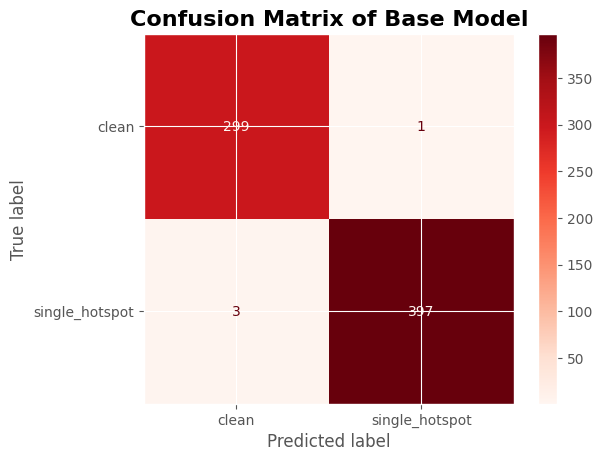

In [34]:
# Prepare confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(test_gen.class_indices.keys()))
disp.plot(cmap=plt.cm.Reds)
plt.title('Confusion Matrix of Base Model', fontsize=16, fontweight='bold')
plt.show()

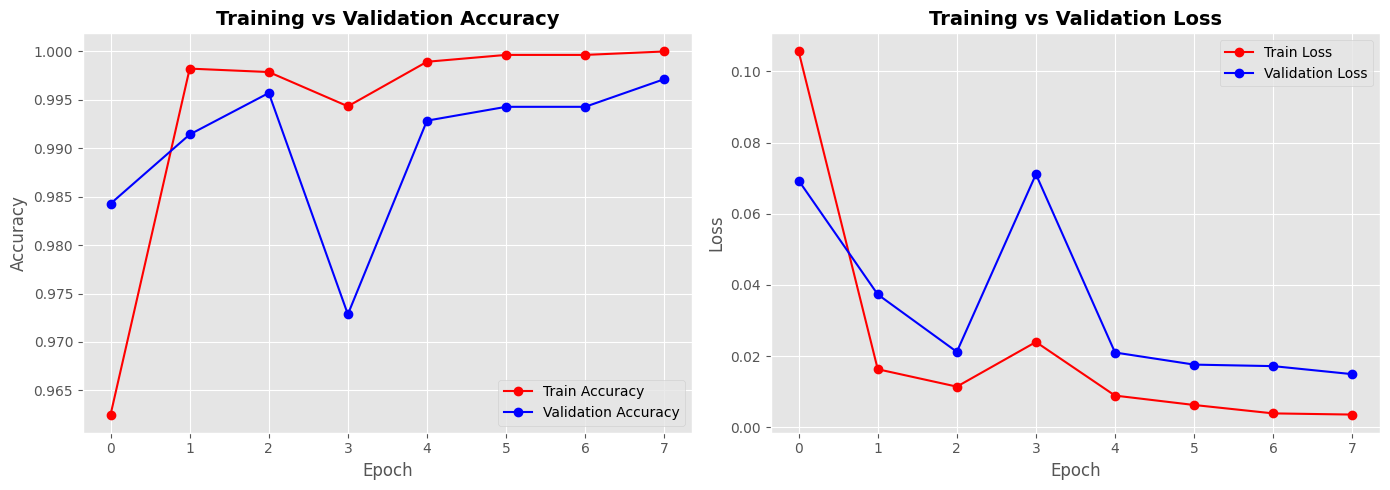

In [35]:
# Plot accuracy and loss curves
plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o', c='red')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o', c='blue')
plt.title('Training vs Validation Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss', marker='o', c='red')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o', c='blue')
plt.title('Training vs Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

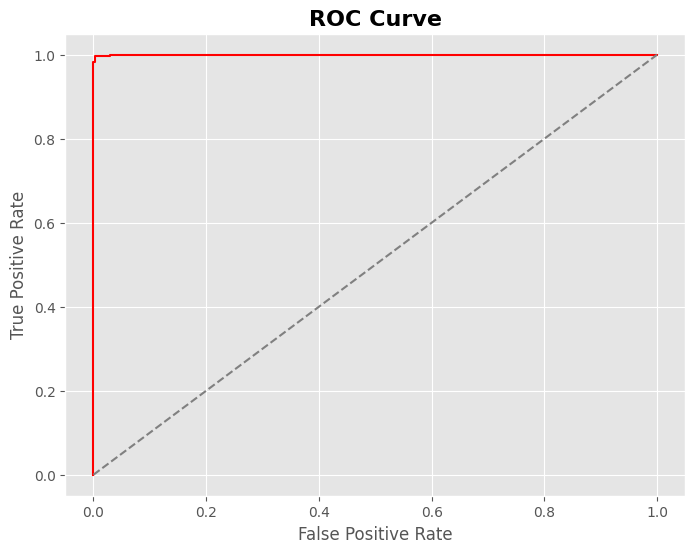

In [36]:
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)

# ROC Curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, c='red')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve', fontsize=16, fontweight='bold')
plt.show()

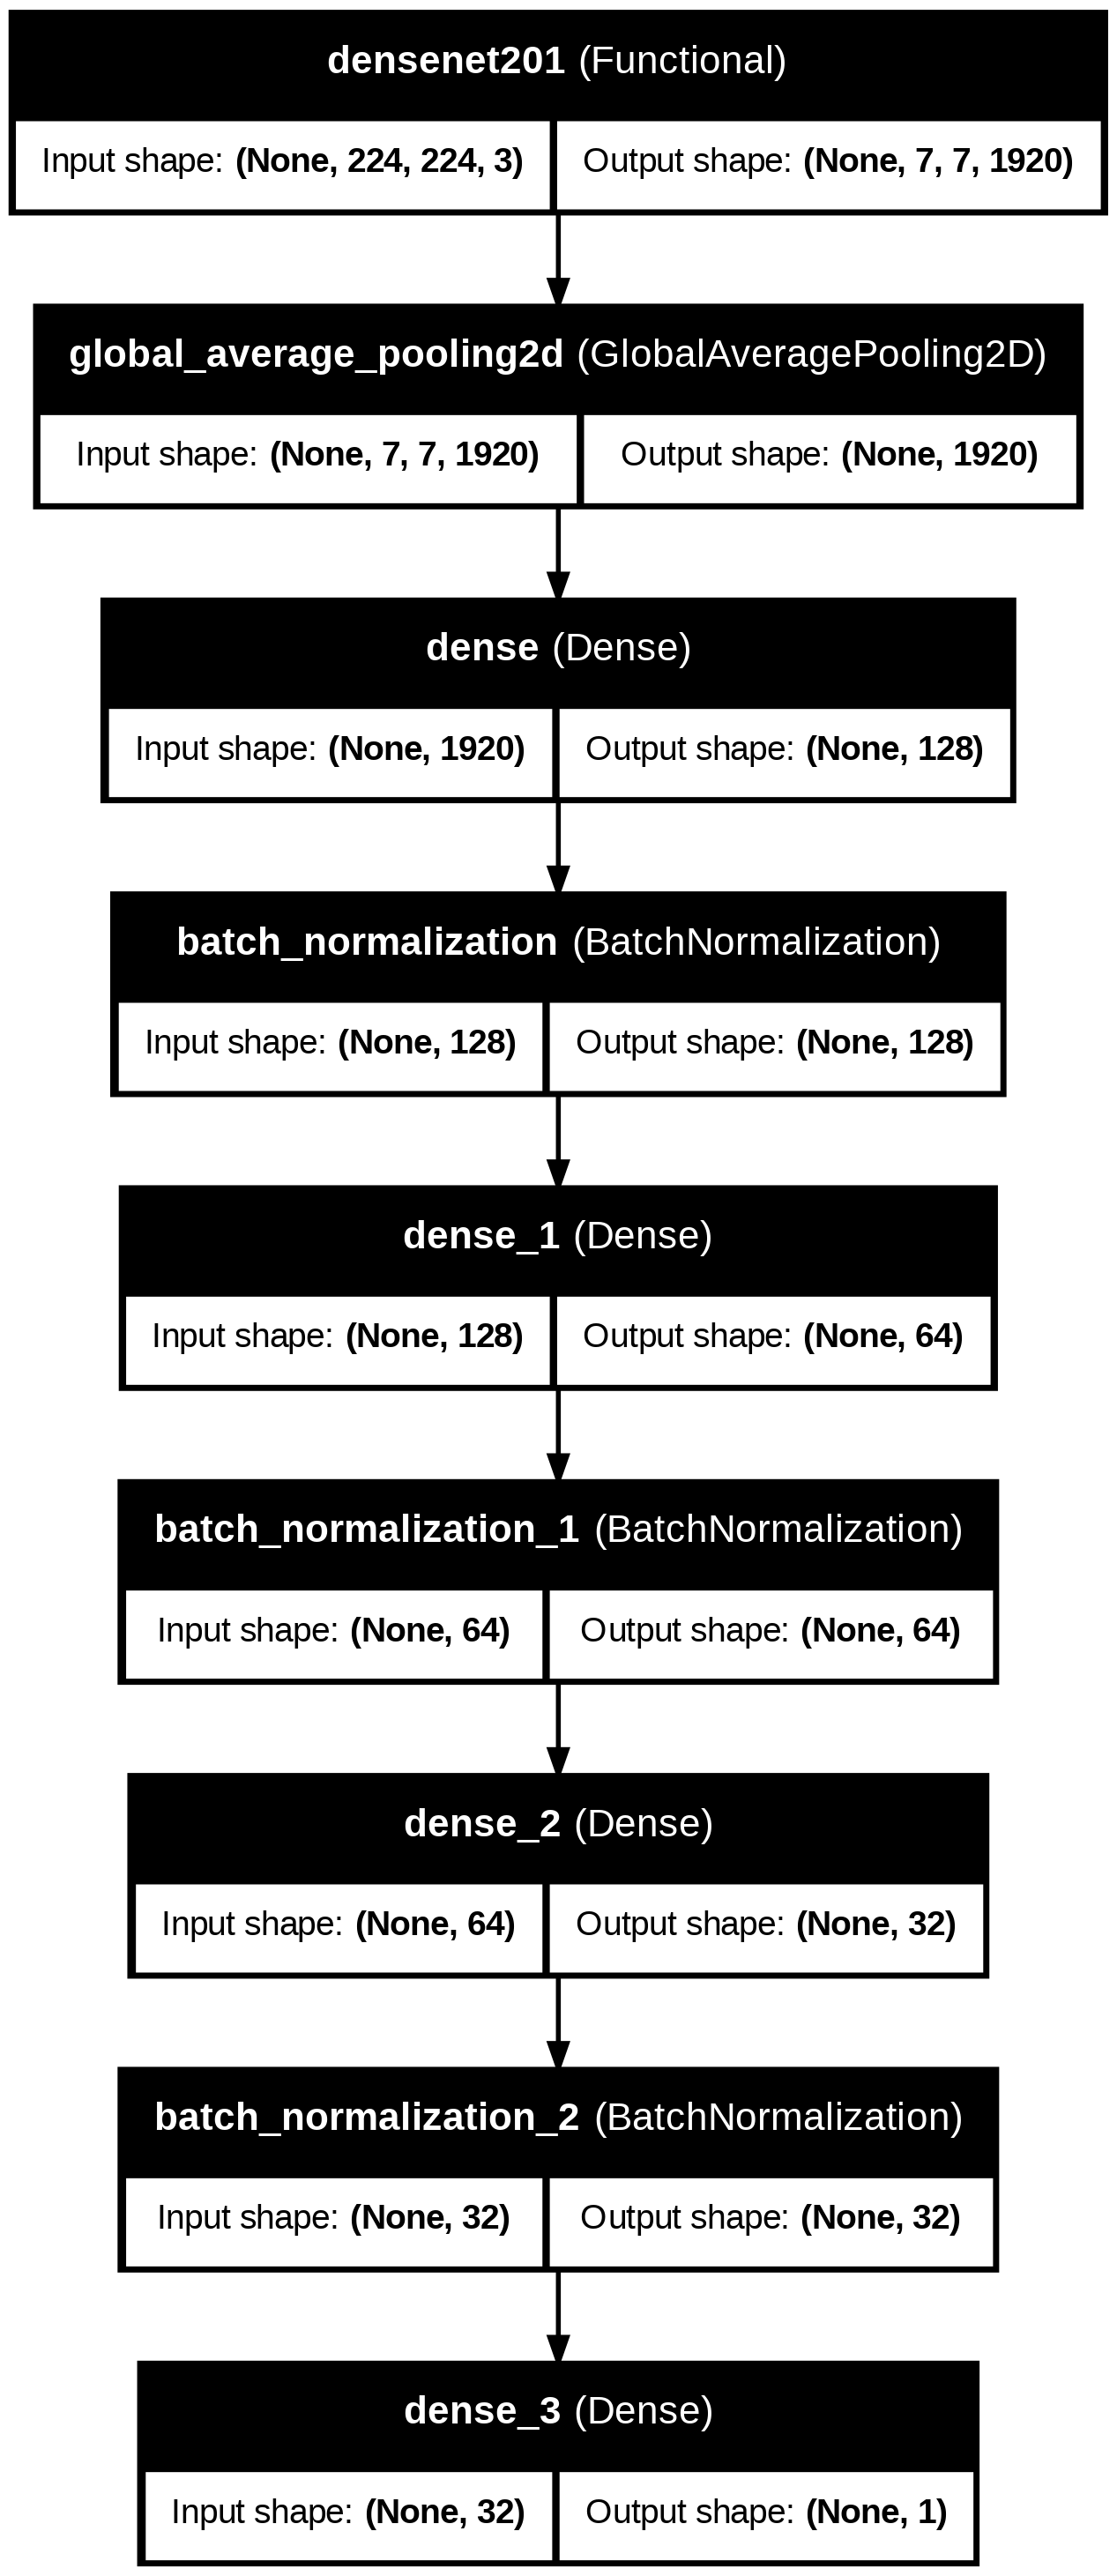

In [41]:
# Plot the model
plot_model(model, to_file='cnn_plot.png', show_shapes=True, show_layer_names=True)

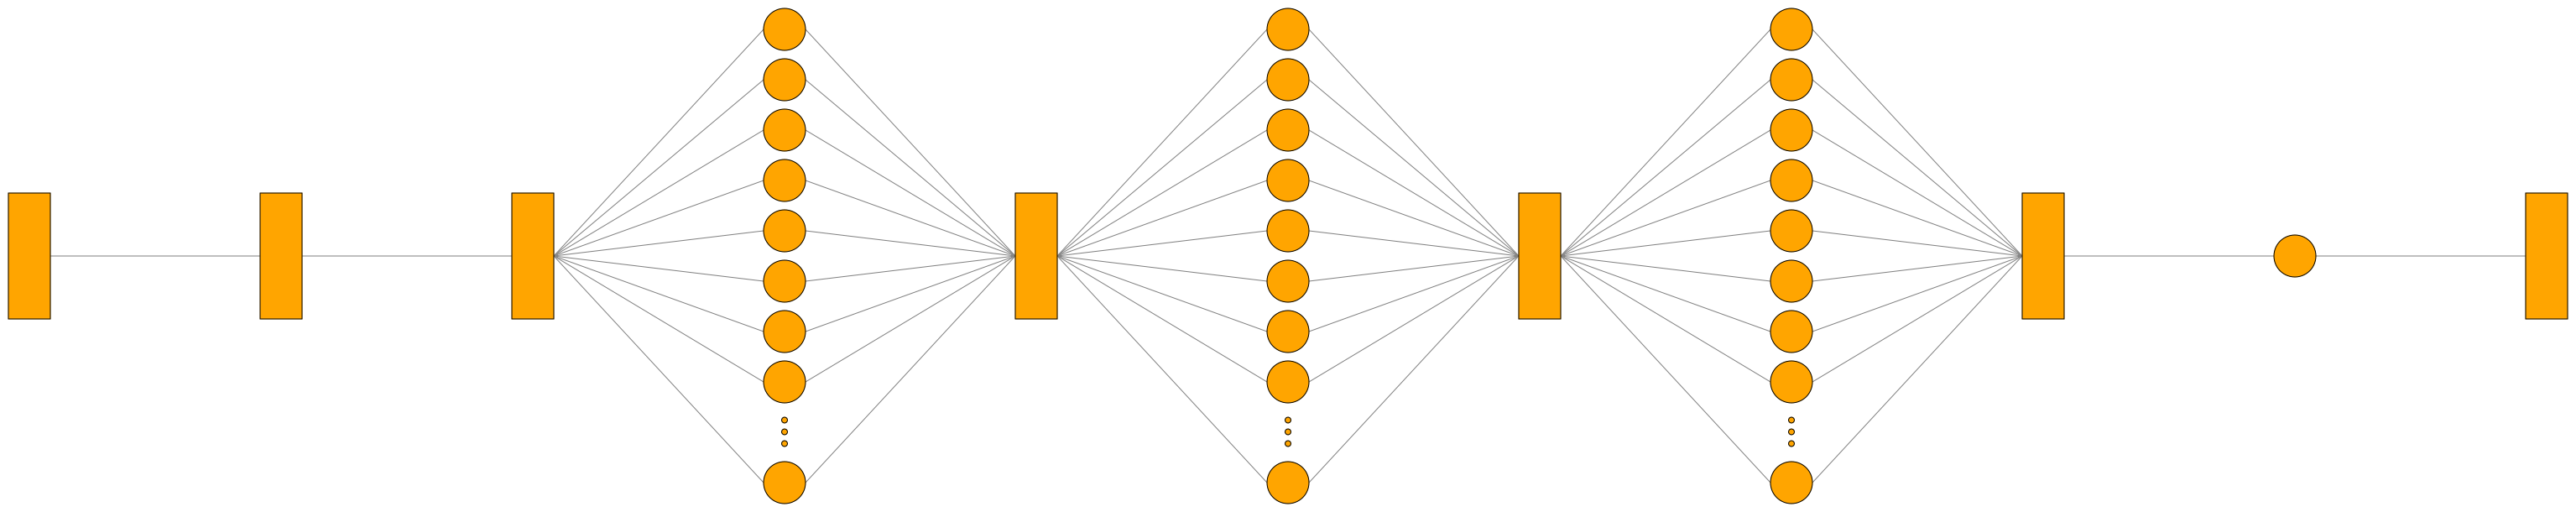

In [56]:
# View nodes
visualkeras.graph_view(
    model,
    background_fill='white'
)

# **6. SHAP For Base Model**

In [58]:
# Take a small batch from training as background
background_images, _ = next(train_gen)
background_images = background_images[:50]

In [59]:
# Take samples from test set
test_images, test_labels = next(test_gen)
test_images = test_images[:10]   # explain 10 images
test_labels = test_labels[:10]

In [60]:
# Create explainer
explainer = shap.GradientExplainer(
    model,
    background_images
)

In [61]:
# Get shap values
shap_values = explainer.shap_values(test_images)

In [62]:
# For this binary classification SHAP returns one output
shap_values = shap_values[0]

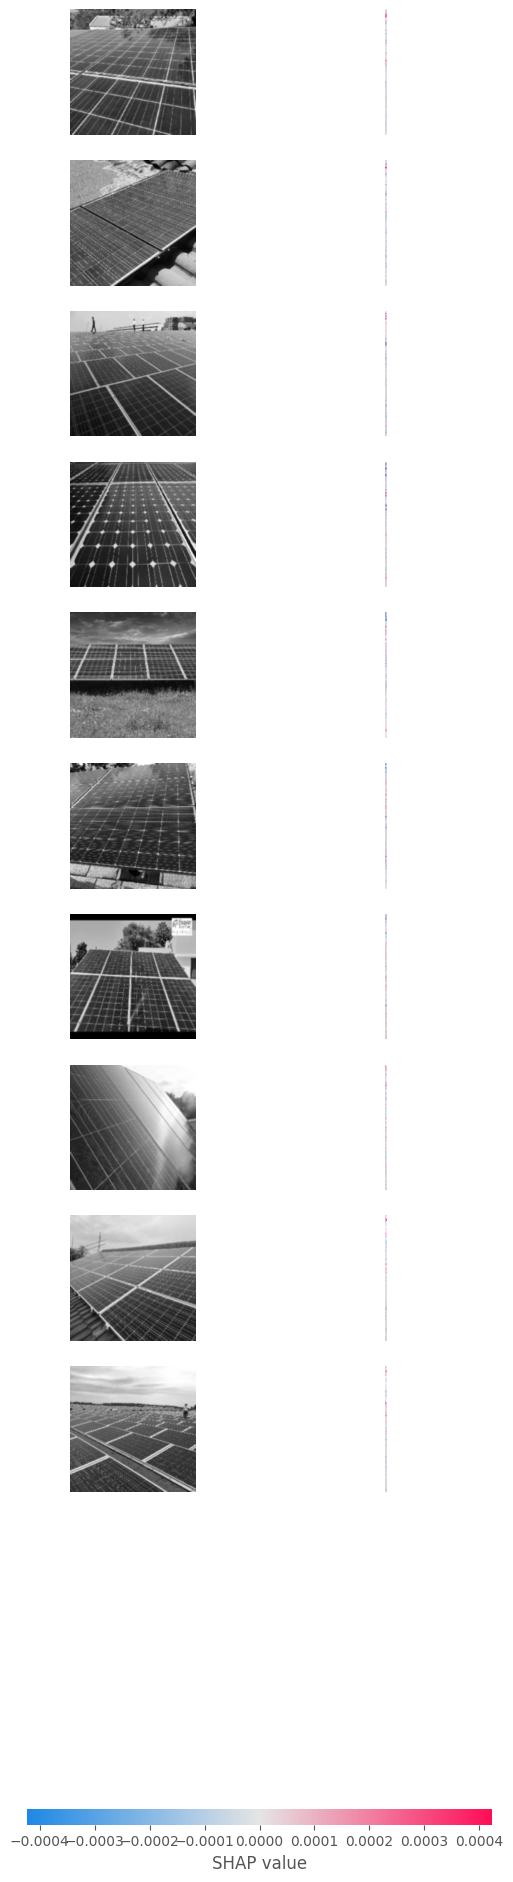

In [63]:
# Plot image plot
shap.image_plot(
    shap_values,
    test_images
)

TypeError: only length-1 arrays can be converted to Python scalars

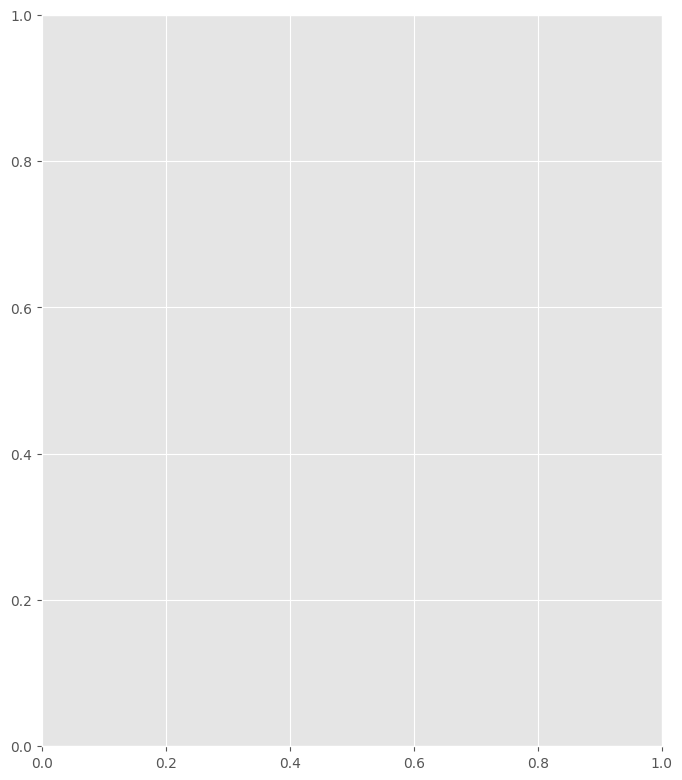

In [65]:
shap.summary_plot(
    shap_values,
    test_images,
    plot_type="bar"
)

In [ ]:
# Pick one image
idx = 0

shap.force_plot(
    explainer.expected_value[0],
    shap_values[idx],
    test_images[idx]
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
Image 0 | Pred prob: 0.002


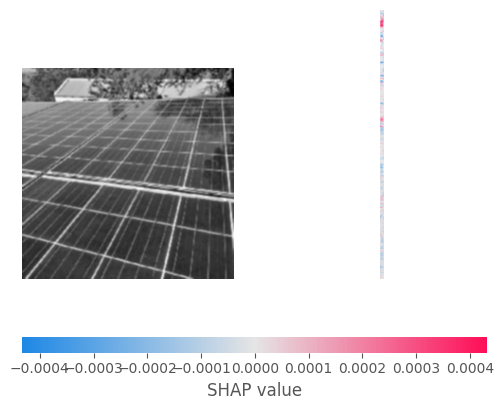

Image 1 | Pred prob: 0.010


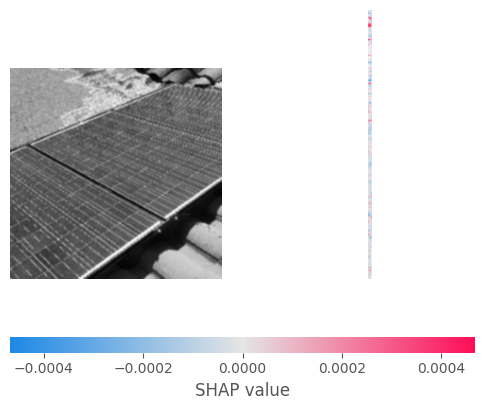

Image 2 | Pred prob: 0.000


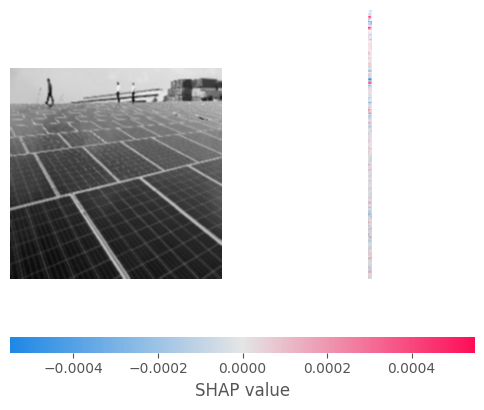

Image 3 | Pred prob: 0.001


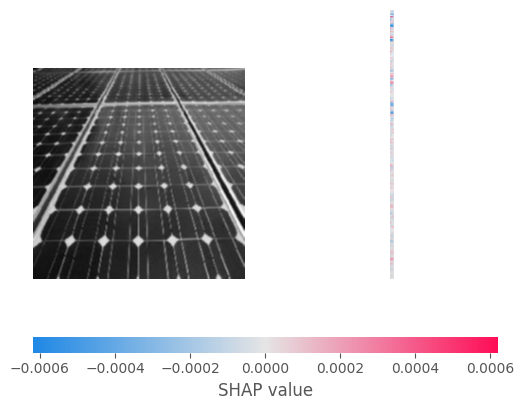

Image 4 | Pred prob: 0.044


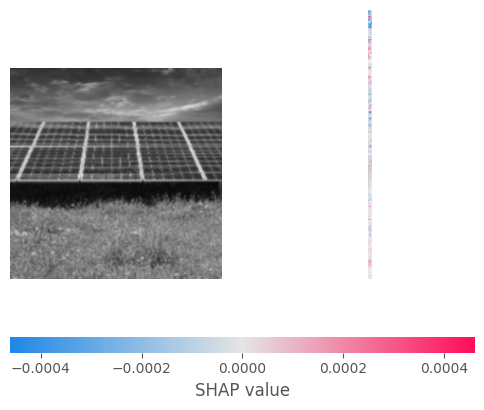

Image 5 | Pred prob: 0.005


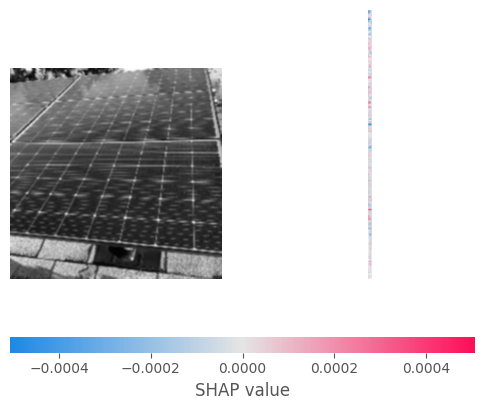

Image 6 | Pred prob: 0.001


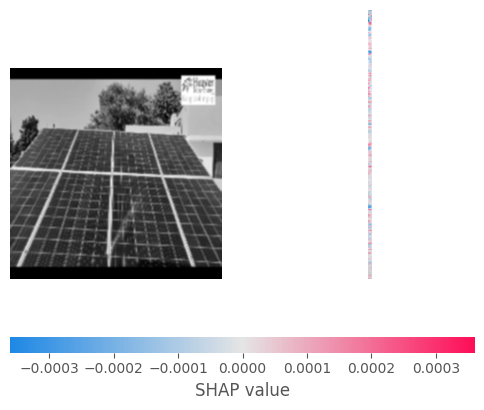

Image 7 | Pred prob: 0.000


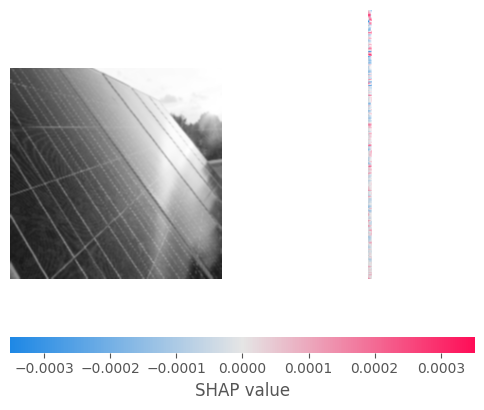

Image 8 | Pred prob: 0.001


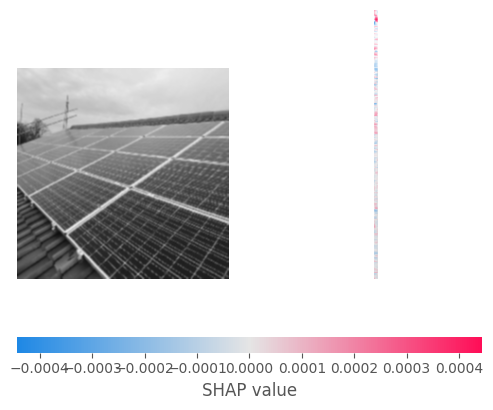

Image 9 | Pred prob: 0.000


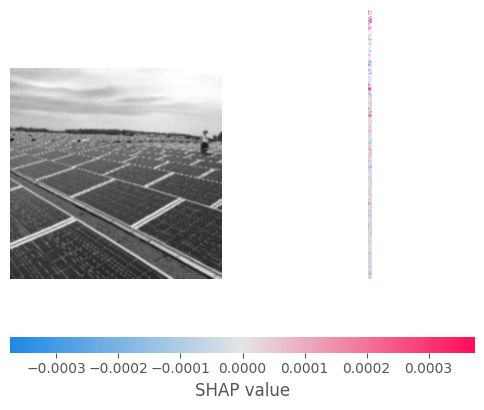

In [64]:
# Separate predictions
pred_probs = model.predict(test_images)

for i in range(len(test_images)):
    print(f"Image {i} | Pred prob: {pred_probs[i][0]:.3f}")
    shap.image_plot(shap_values[i:i+1], test_images[i:i+1])

# **7. Tuning**

In [ ]:
# Train last layers
for layer in base_model.layers[-40:]:
    layer.trainable = True

In [ ]:
# Compile new model
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', AUC(), Precision(), Recall()]
)

In [ ]:
# Train new model
history = model.fit(train_gen, validation_data=val_gen, epochs=10)

In [ ]:
model.evaluate(test_gen)

In [ ]:
y_pred_prob = model.predict(test_gen)
y_pred = (y_pred_prob>0.5).astype(int).flatten()
y_true = test_gen.classes

In [ ]:
print(classification_report(y_true, y_pred, target_names=list(test_gen.class_indices.keys())))

In [ ]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(test_gen.class_indices.keys()))
disp.plot(cmap=plt.cm.Reds)
plt.show()

In [ ]:
# Plot accuracy and loss curves
plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Training vs Validation Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Training vs Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)

# ROC Curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve', fontsize=16, fontweight='bold')
plt.show()